Problem Statement:


To evaluate the three different drugs A,B and C it focuses on blood pressure reduction,recovery and patient to identify the most suitable approach.

Creating Dataset:


In [132]:
import pandas as pd
import numpy as np


In [133]:
data = {
    'Age':[45,50,42,48,52,46,44,49,51],

    'Gender':['M','F','M','F','M','F','M','F','M'],

    'Treatment':['A','A','A','B','B','B','C','C','C'],

    'BP_Before':[150,160,145,155,165,150,158,162,170],

    'BP_After':[135,140,130,125,130,120,118,122,125],

    'PainScore':[3,2,4,1,2,1,1,2,1],

    'RecoveryDays':[10,12,9,7,8,6,5,6,5],

    'Recovered':['No','No','No','Yes','No','Yes','Yes','Yes','Yes']
}

df = pd.DataFrame(data)

In [134]:
df

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered
0,45,M,A,150,135,3,10,No
1,50,F,A,160,140,2,12,No
2,42,M,A,145,130,4,9,No
3,48,F,B,155,125,1,7,Yes
4,52,M,B,165,130,2,8,No
5,46,F,B,150,120,1,6,Yes
6,44,M,C,158,118,1,5,Yes
7,49,F,C,162,122,2,6,Yes
8,51,M,C,170,125,1,5,Yes


In [135]:
# Creating Extra 40 rows 

In [136]:
np.random.seed(42)
n = 40
new_data = {
    'Age': np.random.randint(35, 65, n),
    'Gender': np.random.choice(['M','F'], n),
    'Treatment': np.random.choice(['A','B','C'], n),
    'BP_Before': np.random.randint(140, 180, n),
    'BP_After': np.random.randint(110, 150, n),
    'PainScore': np.random.randint(1, 5, n),
    'RecoveryDays': np.random.randint(4, 14, n),
    'Recovered': np.random.choice(['Yes','No'], n)
}

new_df = pd.DataFrame(new_data)

In [137]:
new_df

,Age,Gender,Treatment,BP_Before,BP_After,PainScore,RecoveryDays,Recovered
0,41,M,A,146,118,1,4,Yes
1,54,F,C,148,124,2,4,No
2,63,F,C,163,124,1,6,Yes
3,49,F,B,140,135,1,5,Yes
4,45,F,A,147,122,3,8,No
5,42,F,B,163,141,2,13,No
6,63,M,B,150,148,4,9,Yes
7,55,F,B,156,141,4,10,Yes
8,41,F,B,147,113,3,7,No
9,60,M,B,174,139,3,10,No


In [138]:
# Combining
df = pd.concat([df, new_df], ignore_index=True)


In [139]:
df.columns

Index(['Age', 'Gender', 'Treatment', 'BP_Before', 'BP_After', 'PainScore',
       'RecoveryDays', 'Recovered'],
      dtype='str')

In [140]:
df["BP_Reduction"] = (df["BP_Before"]- df["BP_After"])

EDA

In [141]:
df.head


<bound method NDFrame.head of     Age Gender Treatment  BP_Before  BP_After  PainScore  RecoveryDays  \
0    45      M         A        150       135          3            10   
1    50      F         A        160       140          2            12   
2    42      M         A        145       130          4             9   
3    48      F         B        155       125          1             7   
4    52      M         B        165       130          2             8   
5    46      F         B        150       120          1             6   
6    44      M         C        158       118          1             5   
7    49      F         C        162       122          2             6   
8    51      M         C        170       125          1             5   
9    41      M         A        146       118          1             4   
10   54      F         C        148       124          2             4   
11   63      F         C        163       124          1             6   
12   49 

In [142]:
df.shape

(49, 9)

In [143]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 49 entries, 0 to 48
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Age           49 non-null     int64
 1   Gender        49 non-null     str  
 2   Treatment     49 non-null     str  
 3   BP_Before     49 non-null     int64
 4   BP_After      49 non-null     int64
 5   PainScore     49 non-null     int64
 6   RecoveryDays  49 non-null     int64
 7   Recovered     49 non-null     str  
 8   BP_Reduction  49 non-null     int64
dtypes: int64(6), str(3)
memory usage: 3.8 KB


In [144]:
df.describe()

,Age,BP_Before,BP_After,PainScore,RecoveryDays,BP_Reduction
count,49.000000,49.000000,49.000000,49.000000,49.000000,49.000000
mean,50.489796,159.326531,130.102041,2.326531,7.877551,29.224490
std,8.406650,12.260009,11.218001,1.179473,2.705185,14.915408
min,35.000000,140.000000,110.000000,1.000000,4.000000,-4.000000
25%,45.000000,148.000000,122.000000,1.000000,6.000000,20.000000
50%,51.000000,161.000000,131.000000,2.000000,7.000000,30.000000
75%,58.000000,172.000000,139.000000,3.000000,10.000000,39.000000
max,64.000000,179.000000,148.000000,4.000000,13.000000,61.000000


In [145]:
df.isnull().sum()

Age             0
Gender          0
Treatment       0
BP_Before       0
BP_After        0
PainScore       0
RecoveryDays    0
Recovered       0
BP_Reduction    0
dtype: int64

In [146]:
df.duplicated().sum()

np.int64(0)

Data Virtualization

In [147]:
import seaborn as sns
import matplotlib.pyplot as plt

In [148]:
df.columns

Index(['Age', 'Gender', 'Treatment', 'BP_Before', 'BP_After', 'PainScore',
       'RecoveryDays', 'Recovered', 'BP_Reduction'],
      dtype='str')

In [149]:
from sklearn.preprocessing import LabelEncoder

l = LabelEncoder()
df["Gender"] = df["Gender"].map({"M": 0, "F": 1})
df["Treatment"] = df["Treatment"].map({"A": 0, "B": 1, "C": 2})
df["Recovered"] = df["Recovered"].map({"No": 0, "Yes": 1})

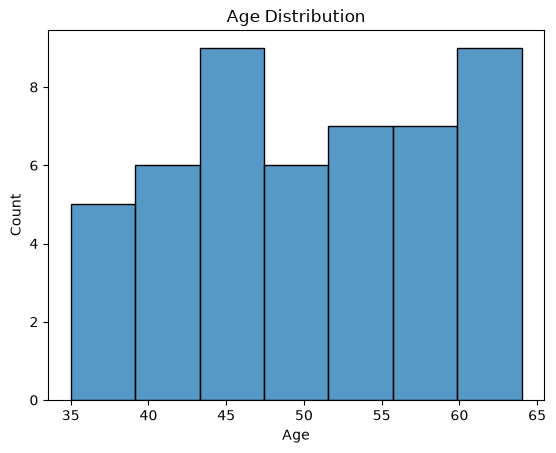

In [150]:
sns.histplot(df["Age"])
plt.title("Age Distribution")
plt.show()

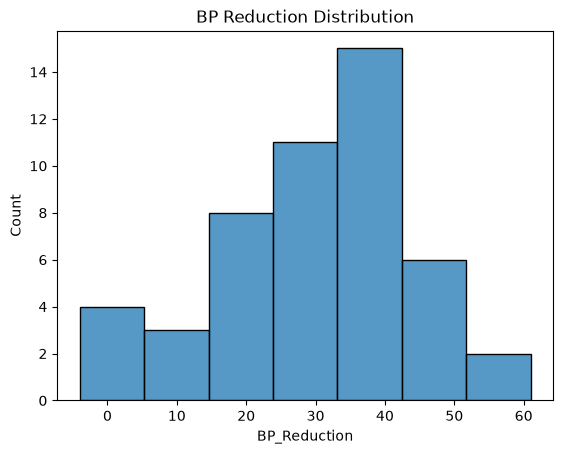

In [151]:
sns.histplot(df["BP_Reduction"])
plt.title("BP Reduction Distribution")
plt.show()

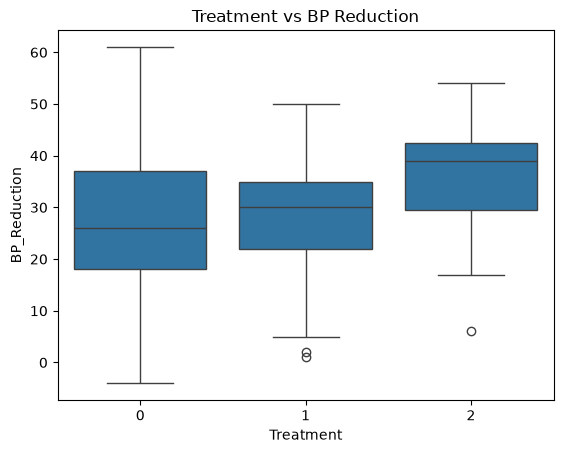

In [152]:
sns.boxplot(
    x="Treatment",
    y="BP_Reduction",
    data=df
)

plt.title("Treatment vs BP Reduction")
plt.show()

Done for Anova because effictiveness of different drugs by showing the distribution of blood pressure reduction for treatment groups.

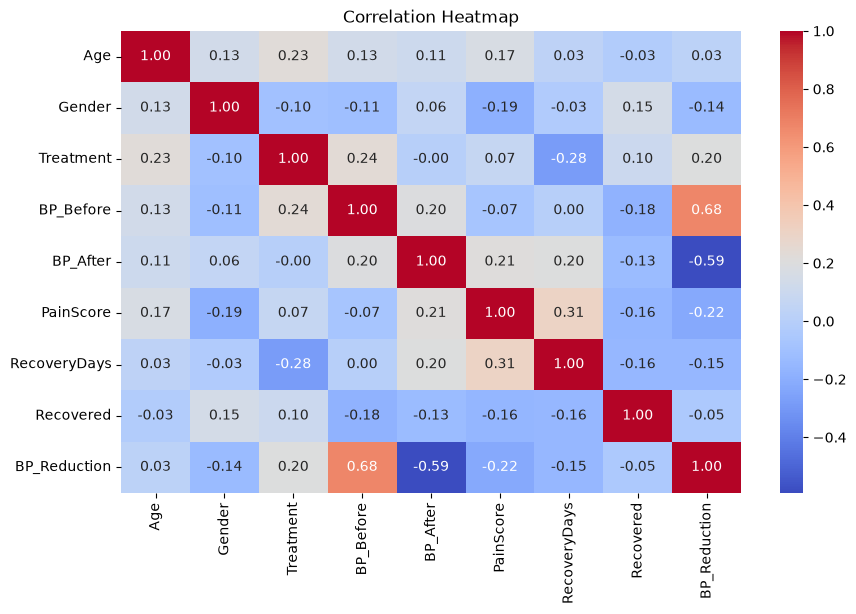

In [153]:
plt.figure(figsize=(10,6))
sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Heatmap")
plt.show()

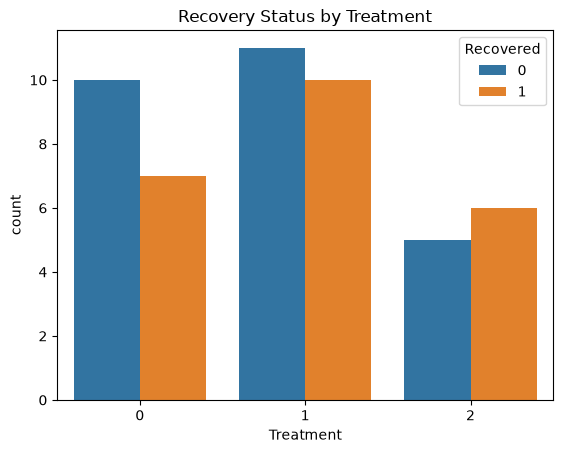

In [154]:
sns.countplot(
    x="Treatment",
    hue="Recovered",
    data=df
)

plt.title("Recovery Status by Treatment")
plt.show()

Compares recover and non-recovered patients of different treatment.

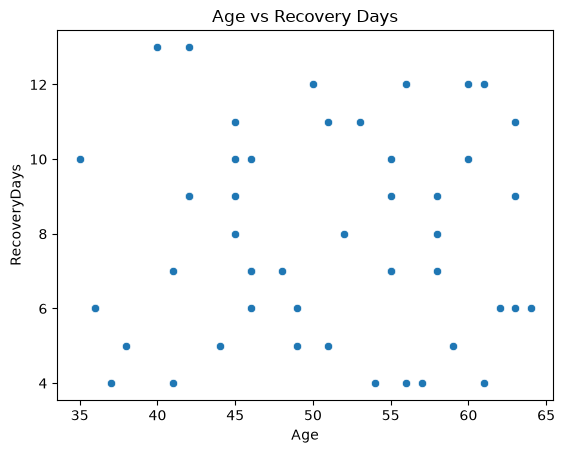

In [155]:
sns.scatterplot(
    x="Age",
    y="RecoveryDays",
    data=df
)

plt.title("Age vs Recovery Days")
plt.show()

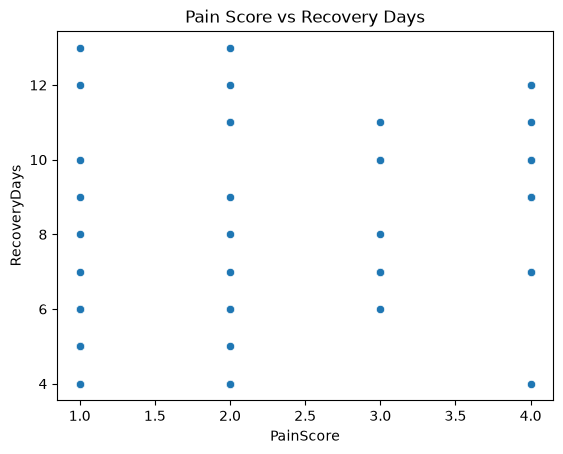

In [156]:
sns.scatterplot(
    x="PainScore",
    y="RecoveryDays",
    data=df
)

plt.title("Pain Score vs Recovery Days")
plt.show()

Higher pain scores require more recovery time.

1. ANOVA TEST: are drugs A, B and C significantly different in there effectiveness?

2. T-TEST: if i compare 2 drugs directly? is one better than the other?

3. Z-TEST: does the average BP reduction meet a target value?

4. CHI-SQUARE TEST: whether the recovery actually depends on the drug or not?

ANOVA Test

In [157]:
from scipy.stats import f_oneway

a = df[df["Treatment"] == 0]["BP_Reduction"]  # Treatment A
b = df[df["Treatment"] == 1]["BP_Reduction"]  # Treatment B
c = df[df["Treatment"] == 2]["BP_Reduction"]  # Treatment C

f_stat, p_value = f_oneway(a, b, c)

print("F Statistic:", f_stat)
print("P Value:", p_value)

F Statistic: 1.2672139104630396
P Value: 0.29126084552299214


In [158]:
if p_value < 0.05:
    print("There is a significant difference between the treatments.")
else:
    print("There is no significant difference between the treatments.")

There is no significant difference between the treatments.


p-value = 0.29126084552299214 is greater than 0.05 we fail to reject the null hypothesis. Indicates there is no statistically significant difference in mean blood pressure reduction among Treatments A, B, and C.

In [159]:
means = df.groupby("Treatment")["BP_Reduction"].mean()
print(means)

Treatment
0    26.941176
1    27.809524
2    35.454545
Name: BP_Reduction, dtype: float64


T-Test

In [160]:
from scipy.stats import ttest_ind

t_stat, p_value = ttest_ind(a, b)

print("T Statistic:", t_stat)
print("P Value:", p_value)

T Statistic: -0.17811815746331724
P Value: 0.8596287216697848


In [161]:
if p_value < 0.05:
    print("Drugs are significantly different")
else:
    print("No significant difference")

No significant difference


In [162]:
a_mean = a.mean()
b_mean = b.mean()

print("Treatment A Mean:", a_mean)
print("Treatment B Mean:", b_mean)

Treatment A Mean: 26.941176470588236
Treatment B Mean: 27.80952380952381


In [163]:
a_mean = a.mean()
b_mean = b.mean()

percentage_diff = ((b_mean - a_mean) / a_mean) * 100

print("Percentage Difference:", percentage_diff, "%")

Percentage Difference: 3.2231233104595565 %


p-value = 0.8596 > 0.05, so this difference is not statistically significant.

In [164]:
a = means[0]
b = means[1]
c = means[2]

print("B over A (%) =", ((b-a)/a)*100)
print("C over A (%) =", ((c-a)/a)*100)
print("C over B (%) =", ((c-b)/b)*100)

B over A (%) = 3.2231233104595565
C over A (%) = 31.5998412068281
C over B (%) = 27.490660024906592


Treatment C higher average reduction the difference is not statistically significant.

Z-Test

In [165]:
from statsmodels.stats.weightstats import ztest

z_stat, p_value = ztest(
    df["BP_Reduction"],
    value=20
)

print("Z Statistic:", z_stat)
print("P Value:", p_value)

Z Statistic: 4.32917622768863
P Value: 1.4966813369466569e-05


In [166]:
if p_value < 0.05:
    print("Average BP reduction differs from target")
else:
    print("Average BP reduction meets target")

Average BP reduction differs from target


Z-test to determine whether the mean blood pressure reduction differs from 20 units. The test produced a Z Statistic of 4.329 and a p-value of 0.000015. The p-value is less than 0.05, the null hypothesis was rejected

In [167]:
from scipy.stats import chi2_contingency

table = pd.crosstab(
    df["Treatment"],
    df["Recovered"]
)

chi2, p, dof, expected = chi2_contingency(table)

print("Chi Square:", chi2)
print("P Value:", p)

Chi Square: 0.4860885065488644
P Value: 0.7842368079569567


In [168]:
if p < 0.05:
    print("Recovery depends on treatment")
else:
    print("Recovery does not depend on treatment")

Recovery does not depend on treatment


After analyzing the data, Treatment C gave the highest average reduction in blood pressure (35.45), compared to Treatment A and Treatment B. However, the statistical tests showed that the difference between the treatments was not strong enough to say that one treatment is definitely better than the others. The recovery results also did not show a clear connection with the treatment given. So, based on the average values, Treatment C looks like the best option, but the data does not provide enough evidence to prove that it is significantly better than Treatments A and B.

Features and Target Variable

In [169]:
df.columns


Index(['Age', 'Gender', 'Treatment', 'BP_Before', 'BP_After', 'PainScore',
       'RecoveryDays', 'Recovered', 'BP_Reduction'],
      dtype='str')

In [170]:
X = df[['Age', 'Gender', 'Treatment', 'BP_Before', 'BP_After', 'PainScore',
       'RecoveryDays', 'BP_Reduction']]
y = df['Recovered']


In [171]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.20,random_state=42)

Logistic Regression

In [172]:
from sklearn.linear_model import LogisticRegression
l = LogisticRegression(max_iter=1000)
l.fit(X_train, y_train)
y_pred_l = l.predict(X_test)

In [173]:
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

print("Accuracy :", accuracy_score(y_test, y_pred_l))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_l))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_l))

Accuracy : 0.2

Confusion Matrix

[[1 7]
 [1 1]]

Classification Report

              precision    recall  f1-score   support

           0       0.50      0.12      0.20         8
           1       0.12      0.50      0.20         2

    accuracy                           0.20        10
   macro avg       0.31      0.31      0.20        10
weighted avg       0.42      0.20      0.20        10



Random Forest

In [174]:
from sklearn.ensemble import RandomForestClassifier
rf = RandomForestClassifier(n_estimators=100,random_state=42)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

In [175]:
print("Accuracy :", accuracy_score(y_test, y_pred_rf))

print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, y_pred_rf))

print("\nClassification Report\n")
print(classification_report(y_test, y_pred_rf))

Accuracy : 0.4

Confusion Matrix

[[3 5]
 [1 1]]

Classification Report

              precision    recall  f1-score   support

           0       0.75      0.38      0.50         8
           1       0.17      0.50      0.25         2

    accuracy                           0.40        10
   macro avg       0.46      0.44      0.38        10
weighted avg       0.63      0.40      0.45        10



In [176]:
print("Logistic Regression Accuracy :",
      accuracy_score(y_test, y_pred_l))

print("Random Forest Accuracy :",
      accuracy_score(y_test, y_pred_rf))

Logistic Regression Accuracy : 0.2
Random Forest Accuracy : 0.4
